In [1]:
print(5)

5


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
# Project paths
BASE_DIR = Path("../data")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "val"
TEST_DIR = BASE_DIR / "test"

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Train directory:", TRAIN_DIR)
print("Validation directory:", VAL_DIR)
print("Test directory:", TEST_DIR)

Train directory: ..\data\train
Validation directory: ..\data\val
Test directory: ..\data\test


In [4]:
# Data Generators

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(train_generator.class_indices.keys())
NUM_CLASSES = len(class_labels)

print("Classes:", class_labels)
print("Number of classes:", NUM_CLASSES)

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Classes: ['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']
Number of classes: 11


In [5]:
# Computing Class Weights

train_class_labels = train_generator.classes

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_class_labels),
    y=train_class_labels
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for class_index, weight in class_weights.items():
    print(f"{class_labels[class_index]}: {weight:.2f}")

Class weights:
animal fish: 0.52
animal fish bass: 18.86
fish sea_food black_sea_sprat: 0.99
fish sea_food gilt_head_bream: 1.00
fish sea_food hourse_mackerel: 0.99
fish sea_food red_mullet: 0.98
fish sea_food red_sea_bream: 0.99
fish sea_food sea_bass: 1.05
fish sea_food shrimp: 0.98
fish sea_food striped_red_mullet: 1.03
fish sea_food trout: 0.98


In [6]:
# Building CNN from scratch

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

cnn_model.summary()

c:\Users\rspmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,830,603 (37.50 MB)

 Trainable params: 9,829,643 (37.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
# Compiling the model

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
# Adding callbacks

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [9]:
# Training the CNN

EPOCHS = 25

cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.2439 - loss: 7.4953 - val_accuracy: 0.1658 - val_loss: 16.0491 - learning_rate: 0.0010
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.2355 - loss: 7.6372 - val_accuracy: 0.2491 - val_loss: 7.1380 - learning_rate: 0.0010
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.2315 - loss: 7.9704 - val_accuracy: 0.2628 - val_loss: 5.7820 - learning_rate: 0.0010
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.2479 - loss: 4.6366 - val_accuracy: 0.2106 - val_loss: 3.0016 - learning_rate: 0.0010
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.2165 - loss: 3.1922 - val_accuracy: 0.1859 - val_loss: 2.1400 - learning_rate: 0.0010
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.2252 - loss: 2.1569 - val_accuracy: 0.3278 - val_loss: 1.8922 - learning_rate: 0.0010
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.2569 - loss: 2

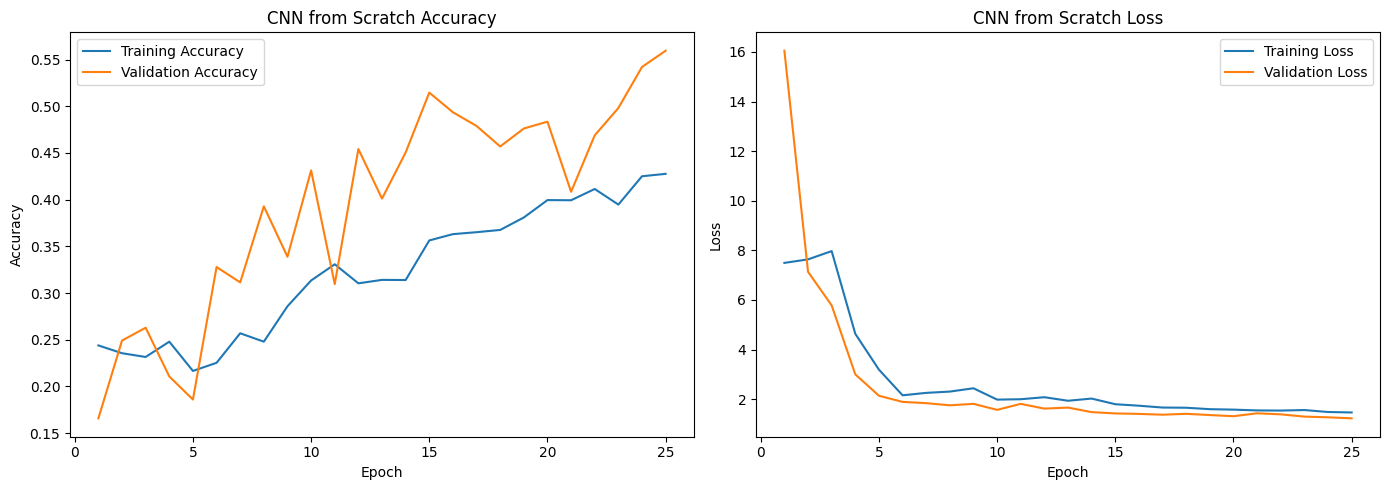

In [10]:
# Plotting training history

def plot_training_history(history, model_name):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(cnn_history, "CNN from Scratch")

In [11]:
# Evaluating Test data

test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 219ms/step - accuracy: 0.5601 - loss: 1.3060
Test Loss: 1.3060
Test Accuracy: 0.5601


In [12]:
# Classification Report

test_generator.reset()

pred_probs = cnn_model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    digits=4
))

100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 233ms/step
                                  precision    recall  f1-score   support

                     animal fish     0.9848    0.7462    0.8490       520
                animal fish bass     0.0484    0.4615    0.0876        13
   fish sea_food black_sea_sprat     0.9518    0.7953    0.8665       298
   fish sea_food gilt_head_bream     0.5625    0.0295    0.0561       305
   fish sea_food hourse_mackerel     0.2931    0.1783    0.2217       286
        fish sea_food red_mullet     0.9143    0.8797    0.8967       291
     fish sea_food red_sea_bream     0.3182    0.5385    0.4000       273
          fish sea_food sea_bass     0.5430    0.3089    0.3938       327
            fish sea_food shrimp     0.6082    0.9239    0.7335       289
fish sea_food striped_red_mullet     0.4716    0.4539    0.4626       293
             fish sea_food trout     0.3270    0.6507    0.4353       292

                        accuracy                         0.5601   

<Figure size 1200x1000 with 0 Axes>

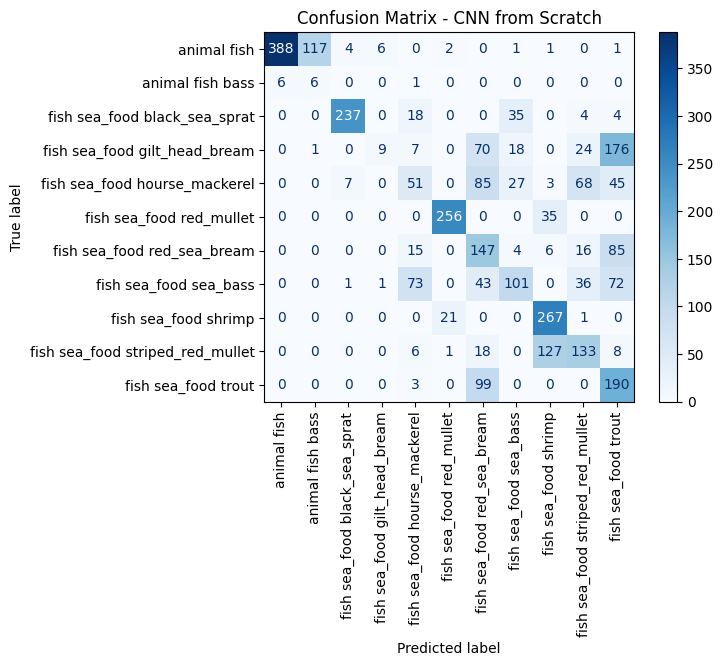

In [13]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)
disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)
plt.title("Confusion Matrix - CNN from Scratch")
plt.show()

In [14]:
MODEL_DIR = BASE_DIR / "../models"
MODEL_DIR.mkdir(exist_ok=True)

cnn_model.save(MODEL_DIR / "../models/cnn_from_scratch.h5")

print("CNN model saved successfully.")

CNN model saved successfully.


The CNN trained from scratch achieved moderate overall accuracy but showed weak performance on several classes, especially minority and visually similar categories. This indicates that transfer learning may be more suitable for the dataset.